O notebook contém o treinamento de vários algoritmos usando pipelines e validação cruzada estratificada de 5-folds.

In [1]:
!pip install feature-engine
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [59]:
import os
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.transformation import LogCpTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn import set_config
from sklearn.base import clone

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
set_config(transform_output='pandas')

ROOT = "/content/drive/MyDrive/ml-project"
FILE = "smart-contract-dataset.csv"
SEED = 78

sys.path.append(os.path.join(ROOT, "modules"))
from custom_transformers import FlagSparseFeatures, OpcodeAggregator, SelectiveInteraction, TreeFeatureSelector

In [ ]:
import importlib
import custom_transformers

importlib.reload(custom_transformers);

In [19]:
# Agregar variáveis "OPCODE" semelhantes.
# Diminui dimensionalide e esparsidade dos dados.
OPCODE_CATEGORIES = {
    'Arithmetic': ['ADD', 'MUL', 'SUB', 'DIV', 'SDIV', 'MOD', 'SMOD', 'ADDMOD', 'MULMOD', 'EXP', 'SIGNEXTEND'],
    'ComparisonLogic': ['LT', 'GT', 'SLT', 'SGT', 'EQ', 'ISZERO', 'AND', 'OR', 'XOR', 'NOT', 'BYTE', 'SHL', 'SHR', 'SAR'],
    'Hashing': ['SHA3'],
    'Environmental': [
        'ADDRESS', 'BALANCE', 'ORIGIN', 'CALLER', 'CALLVALUE',
        'CALLDATALOAD', 'CALLDATASIZE', 'CALLDATACOPY',
        'CODESIZE', 'CODECOPY',
        'GASPRICE', 'EXTCODESIZE', 'EXTCODECOPY', 'RETURNDATASIZE',
        'RETURNDATACOPY', 'BLOCKHASH', 'COINBASE', 'TIMESTAMP',
        'NUMBER', 'DIFFICULTY', 'GASLIMIT',
        'GAS'
    ],
    'Stack_PUSH': [f'PUSH{i}' for i in range(1, 33)],
    'Stack_DUP': [f'DUP{i}' for i in range(1, 17)],
    'Stack_SWAP': [f'SWAP{i}' for i in range(1, 17)],
    'Stack_POP': ['POP'],
    'Memory': ['MLOAD', 'MSTORE', 'MSTORE8', 'MSIZE'],
    'Storage': ['SLOAD', 'SSTORE'],
    'FlowControl': ['JUMP', 'JUMPI', 'PC', 'JUMPDEST', 'STOP'],
    'CallOps': ['CREATE', 'CALL', 'CALLCODE', 'DELEGATECALL', 'STATICCALL'],
    'ReturnOps': ['RETURN', 'REVERT'],
    'Logging': [f'LOG{i}' for i in range(5)], # LOG0, LOG1, LOG2, LOG3, LOG4
    'System': ['INVALID', 'SELFDESTRUCT']
}


# Mostrar resultados das validações cruzadas
def print_cv_results(cv_results):
    print("Training Metrics:")
    print("-" * 40)
    for key, values in cv_results.items():
        if key.startswith("train_"):
            metric = key.replace("train_", "").capitalize()
            mean = np.mean(values)
            std = np.std(values)
            print(f"{metric} Mean: {mean:.4f} | Std: {std:.4f}")

    print()
    print("Test Metrics:")
    print("-" * 40)
    for key, values in cv_results.items():
        if key.startswith("test_"):
            metric = key.replace("test_", "").capitalize()
            mean = np.mean(values)
            std = np.std(values)
            print(f"{metric} Mean: {mean:.4f} | Std: {std:.4f}")

In [4]:
data = pd.read_csv(os.path.join(ROOT, "data", FILE))

In [5]:
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt')
        .replace('>', 'gt')
        .replace('__', '_double_underscore')
        .replace(':', '_colon')
    )
)

In [10]:
more_features = pd.read_csv(os.path.join(ROOT, "data", "solidity_word_counts.csv"))
# Variáveis extraídas dos códigos fontes que contém os contratos inteligentes.
# Representam contagem de termos que são citados no artigo, mas não estão nos dados originais.

In [163]:
more_features.head()

,hash_id,a,account,add,address,allowance,allowed,amount,an,and,approval,args,assert,b,balance,balanceof,balances,be,bool,by,bytes,c,constant,contract,d,decimals,dynargs,e,erc,event,f,false,fn,function,g,i,id,if,in,indexed,is,m,modifier,msg,n,new,newowner,o,of,onlyowner,oracilize,owner,param,price,public,quote,r,returns,s,safemath,sender,solidity,spender,success,symbol,t,that,the,this,to,token,tokens,totalsupply,transfer,true,u,unit,value,w,which,with,x
0,a9f9efa7db92f9cdf44d1dd8a928d88d54550c102ffc63...,1,2,1,26,11,0,8,2,2,0,0,1,0,2,15,1,1,5,1,2,0,0,6,0,3,0,0,0,3,0,0,0,9,0,0,0,4,2,3,2,0,0,11,0,0,0,0,10,0,0,0,13,0,15,0,0,5,1,0,18,1,2,5,3,0,1,40,6,18,1,12,7,7,5,0,0,2,0,0,3,0
1,d3699545134482b5e38c0bce0f3ac2ab63ed14b0d21a02...,25,3,5,59,3,7,10,4,3,2,0,5,13,4,2,15,7,13,6,0,9,25,18,0,1,0,0,0,5,0,5,0,45,0,24,0,20,1,7,15,0,5,17,0,1,8,0,18,5,0,16,13,0,13,0,0,31,1,4,19,2,5,0,1,1,4,53,4,33,10,8,8,15,11,0,0,8,0,7,2,0
2,523cbdaab817a5f810e8d45386bfeb24805de9355b532a...,1,0,0,26,2,6,0,0,1,3,0,0,0,2,2,9,1,7,0,3,0,4,6,0,4,0,0,0,2,0,0,0,14,0,0,0,0,1,4,3,0,0,11,0,0,0,0,1,0,0,0,0,0,6,0,0,11,1,0,11,1,0,7,2,1,2,6,4,4,3,0,2,5,4,0,0,0,0,0,1,0
3,eb206de21bc4c2a90938183ebd26125a29a834e7a0cdad...,5,2,0,32,2,5,4,2,1,2,0,5,5,2,2,10,0,7,3,0,3,9,12,0,3,0,0,0,8,0,4,0,27,0,0,0,6,0,5,8,0,5,14,0,1,5,0,3,9,0,10,1,1,10,0,0,15,0,2,12,1,0,6,1,0,0,14,1,12,3,8,6,8,4,0,0,3,0,1,0,10
4,6222796f1263922061f376b706e5b2c5bf4e05b3350f9a...,18,2,5,55,3,17,8,4,2,4,0,5,13,4,2,15,5,14,7,0,9,0,15,0,2,0,0,0,5,0,2,0,26,0,0,0,6,1,6,14,0,5,25,0,0,7,0,14,4,0,14,11,0,29,0,0,22,0,4,26,2,5,4,2,1,3,47,3,36,7,10,4,14,6,0,0,6,0,7,2,0


In [12]:
data = pd.merge(
    data,
    more_features,
    on='hash_id'
)

In [13]:
X = data.iloc[:, 3:].select_dtypes(include="number")
y = data.label

In [14]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED
)

print(X_train.shape, X_val.shape, X_test.shape)

(23468, 344) (5868, 344) (7335, 344)


### Naive Bayes

In [26]:
feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=0.0001
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        )
    ]
)


naive_bayes_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", GaussianNB()
        )
    ]
)

In [20]:
naive_bayes_cross_validate = cross_validate(
    naive_bayes_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [21]:
print_cv_results(naive_bayes_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7219 | Std: 0.0013
Precision Mean: 0.4641 | Std: 0.0030
Recall Mean: 0.2706 | Std: 0.0057
F1 Mean: 0.3418 | Std: 0.0038
Roc_auc Mean: 0.6487 | Std: 0.0008
Average_precision Mean: 0.3949 | Std: 0.0011

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7209 | Std: 0.0026
Precision Mean: 0.4613 | Std: 0.0075
Recall Mean: 0.2697 | Std: 0.0063
F1 Mean: 0.3403 | Std: 0.0040
Roc_auc Mean: 0.6468 | Std: 0.0041
Average_precision Mean: 0.3925 | Std: 0.0030


In [22]:
# Treino e validaçao para plotar a matriz de confusão
naive_bayes_pipeline.fit(X_train, y_train)
y_pred_naive_bayes = naive_bayes_pipeline.predict(X_val)

In [23]:
print(classification_report(y_val, y_pred_naive_bayes))

              precision    recall  f1-score   support

           0       0.76      0.88      0.81      4238
           1       0.46      0.28      0.35      1630

    accuracy                           0.71      5868
   macro avg       0.61      0.58      0.58      5868
weighted avg       0.68      0.71      0.68      5868



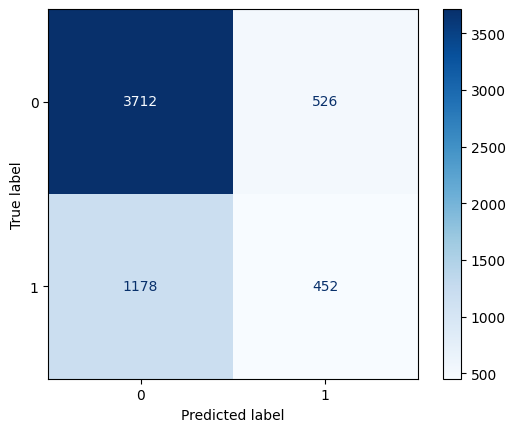

In [25]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_naive_bayes, cmap='Blues');

### Decision Trees

In [32]:
decicion_tree_hyperparameters = {
    "max_depth": 10,
    "class_weight": "balanced",
    "random_state": SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_pipeline = Pipeline(
    [
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "FeatureSelection", feature_selection_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


decision_tree_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Cassifier", DecisionTreeClassifier(
                **decicion_tree_hyperparameters
            )
        )
    ]
)

In [33]:
decision_tree_cross_validate = cross_validate(
    decision_tree_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [34]:
print_cv_results(decision_tree_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7648 | Std: 0.0092
Precision Mean: 0.5451 | Std: 0.0147
Recall Mean: 0.7283 | Std: 0.0180
F1 Mean: 0.6231 | Std: 0.0062
Roc_auc Mean: 0.8367 | Std: 0.0073
Average_precision Mean: 0.6738 | Std: 0.0161

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7235 | Std: 0.0139
Precision Mean: 0.4873 | Std: 0.0186
Recall Mean: 0.6419 | Std: 0.0155
F1 Mean: 0.5537 | Std: 0.0115
Roc_auc Mean: 0.7542 | Std: 0.0042
Average_precision Mean: 0.5433 | Std: 0.0110


In [35]:
decision_tree_pipeline.fit(X_train, y_train)
y_pred_decision_tree = decision_tree_pipeline.predict(X_val)

In [36]:
print(classification_report(y_val, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      4238
           1       0.48      0.64      0.55      1630

    accuracy                           0.70      5868
   macro avg       0.66      0.69      0.66      5868
weighted avg       0.74      0.70      0.72      5868



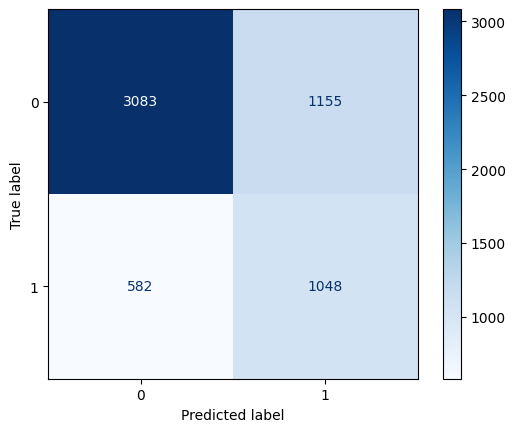

In [37]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_decision_tree, cmap='Blues');

### Logistic Regression

In [41]:
logistic_regression_hyperparameters = {
    'penalty': 'l2',
    'C': 1.0,
    'solver': 'lbfgs',
    'max_iter': 1000,
    'class_weight': 'balanced',
    'random_state': SEED
}

feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)


logistic_regression_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LogisticRegression(
                **logistic_regression_hyperparameters
            )
        )
    ]
)

In [43]:
logistic_regression_cross_validate = cross_validate(
    logistic_regression_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [44]:
print_cv_results(logistic_regression_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7236 | Std: 0.0017
Precision Mean: 0.4861 | Std: 0.0025
Recall Mean: 0.6174 | Std: 0.0051
F1 Mean: 0.5439 | Std: 0.0031
Roc_auc Mean: 0.7585 | Std: 0.0022
Average_precision Mean: 0.5648 | Std: 0.0026

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7147 | Std: 0.0050
Precision Mean: 0.4728 | Std: 0.0073
Recall Mean: 0.6004 | Std: 0.0183
F1 Mean: 0.5290 | Std: 0.0103
Roc_auc Mean: 0.7400 | Std: 0.0063
Average_precision Mean: 0.5361 | Std: 0.0097


In [45]:
logistic_regression_pipeline.fit(X_train, y_train)
y_pred_logistic_regression = logistic_regression_pipeline.predict(X_val)

In [46]:
print(classification_report(y_val, y_pred_logistic_regression))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      4238
           1       0.49      0.60      0.54      1630

    accuracy                           0.72      5868
   macro avg       0.66      0.68      0.67      5868
weighted avg       0.74      0.72      0.72      5868



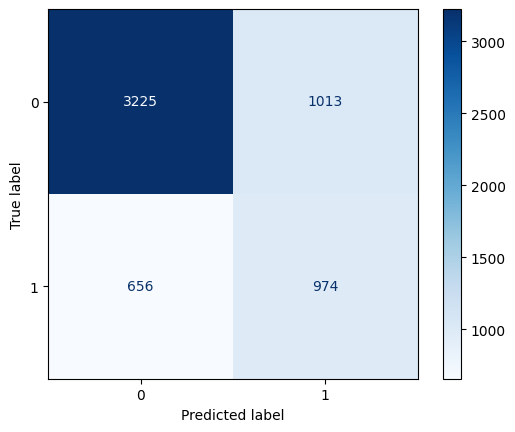

In [47]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_logistic_regression, cmap='Blues');

### Linear SVC

In [50]:
linear_svc_hyperparameters = {
    'C': 1.0,
    'tol': 1e-4,
    'max_iter': 1000,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)


linear_svc_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LinearSVC(
                **linear_svc_hyperparameters
            )
        )
    ]
)

In [51]:
linear_svc_cross_validate = cross_validate(
    linear_svc_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [56]:
print_cv_results(linear_svc_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7233 | Std: 0.0022
Precision Mean: 0.4858 | Std: 0.0032
Recall Mean: 0.6257 | Std: 0.0033
F1 Mean: 0.5469 | Std: 0.0027
Roc_auc Mean: 0.7613 | Std: 0.0010
Average_precision Mean: 0.5590 | Std: 0.0025

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7135 | Std: 0.0075
Precision Mean: 0.4716 | Std: 0.0104
Recall Mean: 0.6049 | Std: 0.0161
F1 Mean: 0.5299 | Std: 0.0103
Roc_auc Mean: 0.7426 | Std: 0.0055
Average_precision Mean: 0.5305 | Std: 0.0099


In [53]:
linear_svc_pipeline.fit(X_train, y_train)
y_pred_linear_svc = linear_svc_pipeline.predict(X_val)

In [54]:
print(classification_report(y_val, y_pred_linear_svc))

              precision    recall  f1-score   support

           0       0.83      0.76      0.80      4238
           1       0.49      0.61      0.54      1630

    accuracy                           0.72      5868
   macro avg       0.66      0.68      0.67      5868
weighted avg       0.74      0.72      0.73      5868



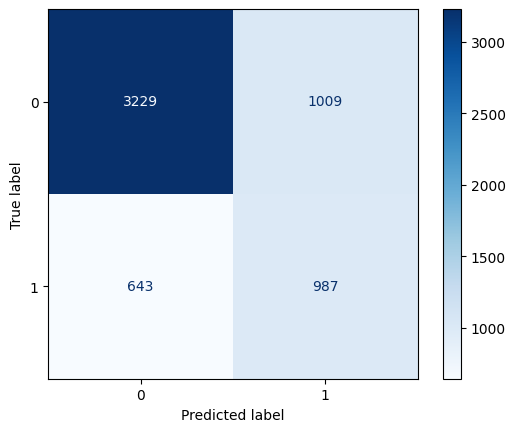

In [55]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_linear_svc, cmap='Blues');

### SVM

In [57]:
svm_hyperparameters = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'tol': 1e-3,
    'max_iter': 15000,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_pipeline = Pipeline(
    [
        (
            "TreeFeatureSelector", TreeFeatureSelector(k=30)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "FeatureSelection", feature_selection_pipeline
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)


svm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", SVC(
                **svm_hyperparameters
            )
        )
    ]
)

In [ ]:
svm_cross_validate = cross_validate(
    svm_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [ ]:
print_cv_results(svm_cross_validate)

In [ ]:
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_val)

In [ ]:
print(classification_report(y_val, y_pred_svm))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm, cmap="Blues");

### Random Forest

In [63]:
random_forest_hyperparameters = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_steps = [
    (
        "TreeFeatureSelector", TreeFeatureSelector(k=50)
    )
]


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "FeatureSelection", feature_selection_pipeline
        ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)

random_forest_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", RandomForestClassifier(
                **random_forest_hyperparameters
            )
        )
    ]
)

In [64]:
random_forest_cross_validate = cross_validate(
    random_forest_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [66]:
print_cv_results(random_forest_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.8206 | Std: 0.0030
Precision Mean: 0.6444 | Std: 0.0064
Recall Mean: 0.7324 | Std: 0.0065
F1 Mean: 0.6856 | Std: 0.0041
Roc_auc Mean: 0.8952 | Std: 0.0020
Average_precision Mean: 0.7800 | Std: 0.0046

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7612 | Std: 0.0066
Precision Mean: 0.5464 | Std: 0.0116
Recall Mean: 0.6225 | Std: 0.0068
F1 Mean: 0.5819 | Std: 0.0088
Roc_auc Mean: 0.8062 | Std: 0.0060
Average_precision Mean: 0.6267 | Std: 0.0082


In [67]:
random_forest_pipeline.fit(X_train, y_train)
y_pred_random_forest = random_forest_pipeline.predict(X_val)

In [68]:
print(classification_report(y_val, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      4238
           1       0.57      0.63      0.60      1630

    accuracy                           0.76      5868
   macro avg       0.71      0.72      0.72      5868
weighted avg       0.77      0.76      0.77      5868



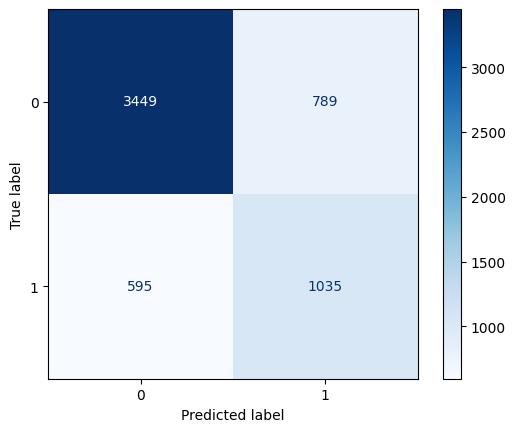

In [70]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_random_forest, cmap="Blues");

### Adaboost

In [71]:
adaboost_hyperparameters = {
    'estimator': DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    'n_estimators': 50,
    'learning_rate': 0.05,
    'random_state': SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_steps = [
    (
        "TreeFeatureSelector", TreeFeatureSelector(k=50)
    )
]


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "FeatureSelection", feature_selection_pipeline
        ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)

adaboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", AdaBoostClassifier(
                **adaboost_hyperparameters
            )
        )
    ]
)

In [72]:
adaboost_cross_validate = cross_validate(
    adaboost_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [73]:
print_cv_results(adaboost_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7272 | Std: 0.0019
Precision Mean: 0.4902 | Std: 0.0030
Recall Mean: 0.5399 | Std: 0.0104
F1 Mean: 0.5138 | Std: 0.0038
Roc_auc Mean: 0.7113 | Std: 0.0056
Average_precision Mean: 0.4342 | Std: 0.0070

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7273 | Std: 0.0032
Precision Mean: 0.4901 | Std: 0.0055
Recall Mean: 0.5397 | Std: 0.0188
F1 Mean: 0.5136 | Std: 0.0108
Roc_auc Mean: 0.7081 | Std: 0.0120
Average_precision Mean: 0.4321 | Std: 0.0130


In [74]:
adaboost_pipeline.fit(X_train, y_train)
y_pred_adaboost = adaboost_pipeline.predict(X_val)

In [75]:
print(classification_report(y_val, y_pred_adaboost))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      4238
           1       0.50      0.54      0.52      1630

    accuracy                           0.73      5868
   macro avg       0.66      0.67      0.66      5868
weighted avg       0.73      0.73      0.73      5868



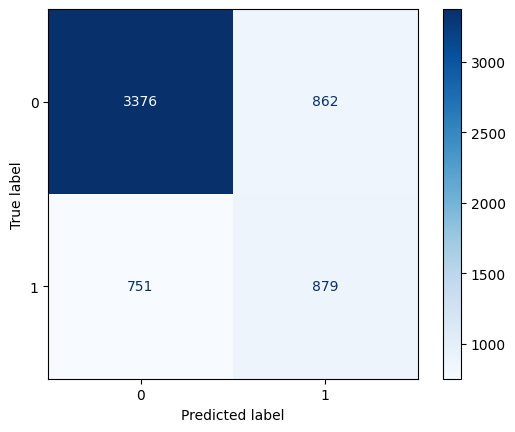

In [76]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_adaboost, cmap="Blues");

### XGBoost

In [118]:
xgboost_hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": 3,
    "learning_rate": 0.03,
    "max_depth":5,
    "min_child_weight": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 5.0,
    "alpha": 1.0,
    "gamma": 0.5,
    "n_estimators": 400,
    "verbosity": 1,
    "random_state": SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_pipeline = [
    (
        "TreeFeatureSelector", TreeFeatureSelector(k=50)
    )
]


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        # (
        #     "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        # ),
        # (
        #     "FeatureSelection", feature_selection_pipeline
        # ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)


xgboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", XGBClassifier(
                **xgboost_hyperparameters
            )
        )
    ]
)

In [119]:
xgboost_cross_validate = cross_validate(
    xgboost_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [120]:
print_cv_results(xgboost_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.7873 | Std: 0.0012
Precision Mean: 0.5731 | Std: 0.0018
Recall Mean: 0.7962 | Std: 0.0030
F1 Mean: 0.6665 | Std: 0.0017
Roc_auc Mean: 0.8797 | Std: 0.0011
Average_precision Mean: 0.7554 | Std: 0.0016

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7423 | Std: 0.0061
Precision Mean: 0.5125 | Std: 0.0082
Recall Mean: 0.7149 | Std: 0.0111
F1 Mean: 0.5970 | Std: 0.0081
Roc_auc Mean: 0.8179 | Std: 0.0053
Average_precision Mean: 0.6579 | Std: 0.0063


In [121]:
xgboost_pipeline.fit(X_train, y_train)
y_pred_xgboost = xgboost_pipeline.predict(X_val)

In [122]:
print(classification_report(y_val, y_pred_xgboost))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      4238
           1       0.54      0.72      0.62      1630

    accuracy                           0.75      5868
   macro avg       0.71      0.74      0.72      5868
weighted avg       0.78      0.75      0.76      5868



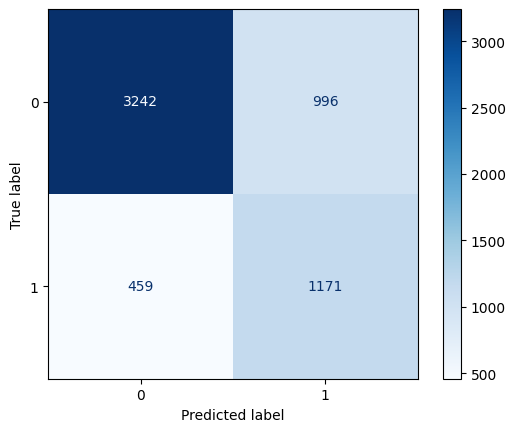

In [123]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgboost, cmap="Blues");

### LightGBM

In [152]:
lightgbm_hyperparameters = {
    "objective": "binary",
    "metric": "aucpr",
    "is_unbalance": True,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "min_child_weight": 1e-3,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "n_estimators": 500,
    "verbosity": -1,
    "random_state": SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=0.0001
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_reduction_pipeline
        ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)


lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

In [153]:
lightgbm_cross_validate = cross_validate(
    lightgbm_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [154]:
print_cv_results(lightgbm_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.8753 | Std: 0.0010
Precision Mean: 0.7176 | Std: 0.0026
Recall Mean: 0.8786 | Std: 0.0029
F1 Mean: 0.7900 | Std: 0.0012
Roc_auc Mean: 0.9472 | Std: 0.0005
Average_precision Mean: 0.8752 | Std: 0.0015

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7730 | Std: 0.0066
Precision Mean: 0.5621 | Std: 0.0112
Recall Mean: 0.6792 | Std: 0.0103
F1 Mean: 0.6151 | Std: 0.0086
Roc_auc Mean: 0.8301 | Std: 0.0055
Average_precision Mean: 0.6758 | Std: 0.0072


In [155]:
lightgbm_pipeline.fit(X_train, y_train)
y_pred_lightgbm = lightgbm_pipeline.predict(X_val)

In [156]:
print(classification_report(y_val, y_pred_lightgbm))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4238
           1       0.59      0.69      0.64      1630

    accuracy                           0.78      5868
   macro avg       0.73      0.75      0.74      5868
weighted avg       0.79      0.78      0.79      5868



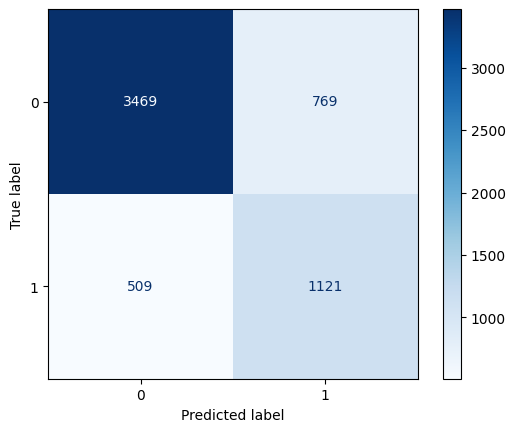

In [157]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lightgbm, cmap="Blues");

### CatBoost

In [169]:
catboost_hyperparaters = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3,
    "random_strength": 1.5,
    "bagging_temperature": 1.0,
    "border_count": 128,
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "scale_pos_weight": 3,
    "verbose": 0,
    "task_type": "CPU",
    "random_seed": SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


feature_selection_pipeline = [
    (
        "TreeFeatureSelector", TreeFeatureSelector(k=50)
    )
]


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        # (
        #     "FeatureSelection", feature_selection_pipeline
        # ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)


catboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", CatBoostClassifier(
                **catboost_hyperparaters
            )
        )
    ]
)

In [170]:
catboost_cross_validate = cross_validate(
    catboost_pipeline,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    return_train_score=True,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
)

In [171]:
print_cv_results(catboost_cross_validate)

Training Metrics:
----------------------------------------
Accuracy Mean: 0.8475 | Std: 0.0032
Precision Mean: 0.6619 | Std: 0.0053
Recall Mean: 0.8765 | Std: 0.0029
F1 Mean: 0.7542 | Std: 0.0045
Roc_auc Mean: 0.9324 | Std: 0.0019
Average_precision Mean: 0.8449 | Std: 0.0038

Test Metrics:
----------------------------------------
Accuracy Mean: 0.7612 | Std: 0.0037
Precision Mean: 0.5404 | Std: 0.0055
Recall Mean: 0.7067 | Std: 0.0121
F1 Mean: 0.6124 | Std: 0.0064
Roc_auc Mean: 0.8252 | Std: 0.0049
Average_precision Mean: 0.6680 | Std: 0.0053


In [172]:
catboost_pipeline.fit(X_train, y_train)
y_pred_catboost = catboost_pipeline.predict(X_val)

In [173]:
print(classification_report(y_val, y_pred_catboost))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4238
           1       0.57      0.70      0.62      1630

    accuracy                           0.77      5868
   macro avg       0.72      0.75      0.73      5868
weighted avg       0.79      0.77      0.77      5868



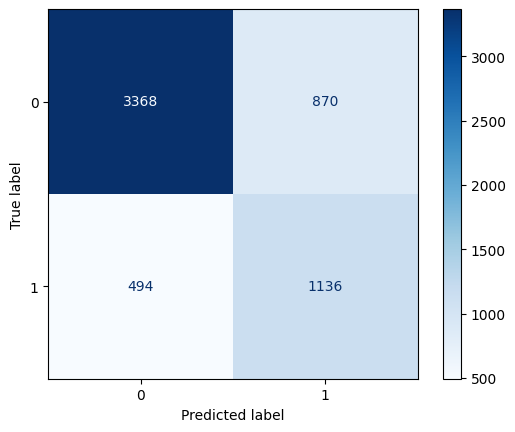

In [174]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_catboost, cmap="Blues");